# Simple CNN — CIFAR-10
### Visualizations + Ablation Experiments


## Step 1: Installs & Imports

In [2]:
!pip install "numpy<2.0"

In [1]:
!pip install captum -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from captum.attr import Saliency

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ['airplane','auto','bird','cat','deer','dog','frog','horse','ship','truck']
print('Device:', device)

Device: cuda


## Step 2: Load CIFAR-10

100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s]


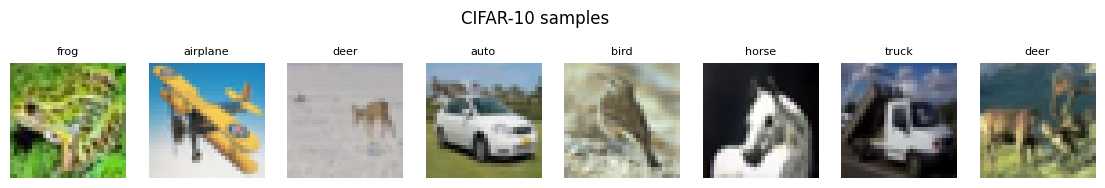

In [2]:
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)

train_tf = T.Compose([T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(MEAN, STD)])
test_tf  = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

trainset = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=128, shuffle=False, num_workers=2)

def denorm(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return (t * s + m).clamp(0, 1)


imgs, labels = next(iter(trainloader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(denorm(imgs[i]).permute(1,2,0))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 samples', y=1.05)
plt.show()

## Step 3: Define the Model

A simple 3-block CNN:
```
Input 3×32×32
  Block 1: Conv(3→32)  → BN → ReLU → MaxPool   →  32×16×16
  Block 2: Conv(32→64) → BN → ReLU → MaxPool   →  64×8×8
  Block 3: Conv(64→128)→ BN → ReLU → MaxPool   → 128×4×4
  Flatten → FC(2048→256) → ReLU → FC(256→10)
```
We store intermediate activations in `self.feature_maps` so we can visualize them later.

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, use_bn=True, activation='relu', dropout_p=0.0):
        super().__init__()

        act_map = {'relu': nn.ReLU(), 'leaky': nn.LeakyReLU(0.1), 'gelu': nn.GELU()}
        self.act = act_map[activation]

        # conv blocks (3 blocks)   INPUT = 3*32*32
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1) # Block 1 (32*16*16)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1) # Block 2 (64*8*8)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1) # Block 3 (128*4*4)

        # batch norm
        self.bn1 = nn.BatchNorm2d(32)  if use_bn else nn.Identity()
        self.bn2 = nn.BatchNorm2d(64)  if use_bn else nn.Identity()
        self.bn3 = nn.BatchNorm2d(128) if use_bn else nn.Identity()

        self.pool = nn.MaxPool2d(2, 2)

        # classifier
        self.fc1     = nn.Linear(128 * 4 * 4, 256)   #Input neurons  = 128*4*4 = 2048, hidden layer neurons = 256
        self.dropout = nn.Dropout(dropout_p)
        self.fc2     = nn.Linear(256, 10) # hidden layer neurons = 256, output layer neurons = 10 (10 output classes)

        # storage for visualization
        self.feature_maps = {}

    def forward(self, x):  #forward pass
        x = self.pool(self.act(self.bn1(self.conv1(x))))
        self.feature_maps['block1'] = x.detach().cpu()

        x = self.pool(self.act(self.bn2(self.conv2(x))))
        self.feature_maps['block2'] = x.detach().cpu()

        x = self.pool(self.act(self.bn3(self.conv3(x))))
        self.feature_maps['block3'] = x.detach().cpu()

        x = x.view(x.size(0), -1)           # flatten
        x = self.dropout(self.act(self.fc1(x)))
        self.feature_maps['penultimate'] = x.detach().cpu()
        return self.fc2(x)

# quick model sanity check
dummy = torch.zeros(2, 3, 32, 32)
out   = SimpleCNN()(dummy)
print('Output shape:', out.shape)   # should be (2, 10)

Output shape: torch.Size([2, 10])


## Step 4: Train

In [4]:
def train(model, epochs=20, lr=0.01):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, test_accs, train_losses = [], [], []

    for epoch in range(1, epochs + 1):
        # --- training ---
        model.train()
        correct, total, loss_sum = 0, 0, 0.0
        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += imgs.size(0)
        scheduler.step()
        train_accs.append(100 * correct / total)
        train_losses.append(loss_sum / total)

        # --- evaluation ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in testloader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total   += imgs.size(0)
        test_accs.append(100 * correct / total)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:>2}/{epochs}  '
                  f'Train: {train_accs[-1]:.1f}%  Test: {test_accs[-1]:.1f}%')

    return model, train_accs, test_accs, train_losses


print('Training baseline model...')
model, train_accs, test_accs, train_losses = train(SimpleCNN())

Training baseline model...
Epoch  1/20  Train: 33.7%  Test: 50.9%
Epoch  5/20  Train: 73.0%  Test: 70.3%
Epoch 10/20  Train: 82.4%  Test: 76.4%
Epoch 15/20  Train: 89.2%  Test: 78.0%
Epoch 20/20  Train: 92.8%  Test: 78.5%


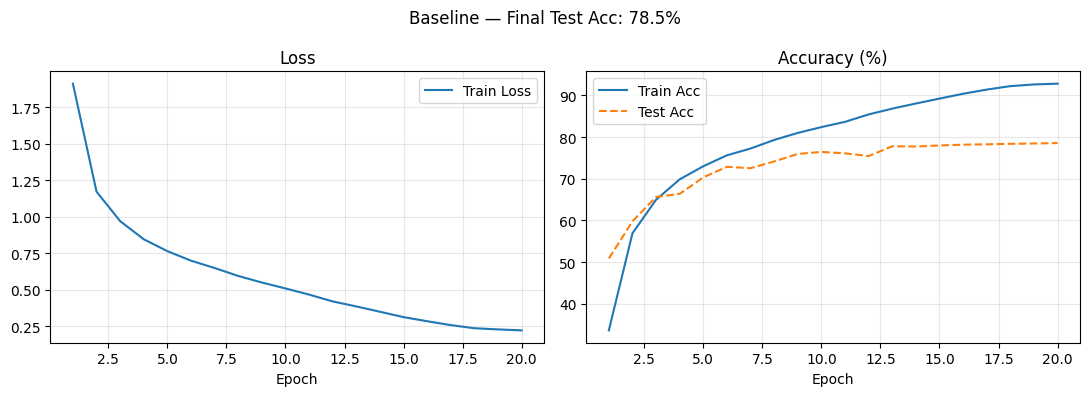

In [5]:
# training curves
epochs = range(1, len(train_accs) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, train_losses, label='Train Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, label='Train Acc')
axes[1].plot(epochs, test_accs,  label='Test Acc', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Baseline — Final Test Acc: {test_accs[-1]:.1f}%', fontsize=12)
plt.tight_layout()
plt.show()

---
# Visualizations

## Visualization 1: Filter Visualization

The raw learned weights of `conv1` (first layer). Each 3×3 patch is one filter.

**What it looks for:** Edge detectors, color blobs, oriented lines — these are the low-level patterns the network learned to detect.

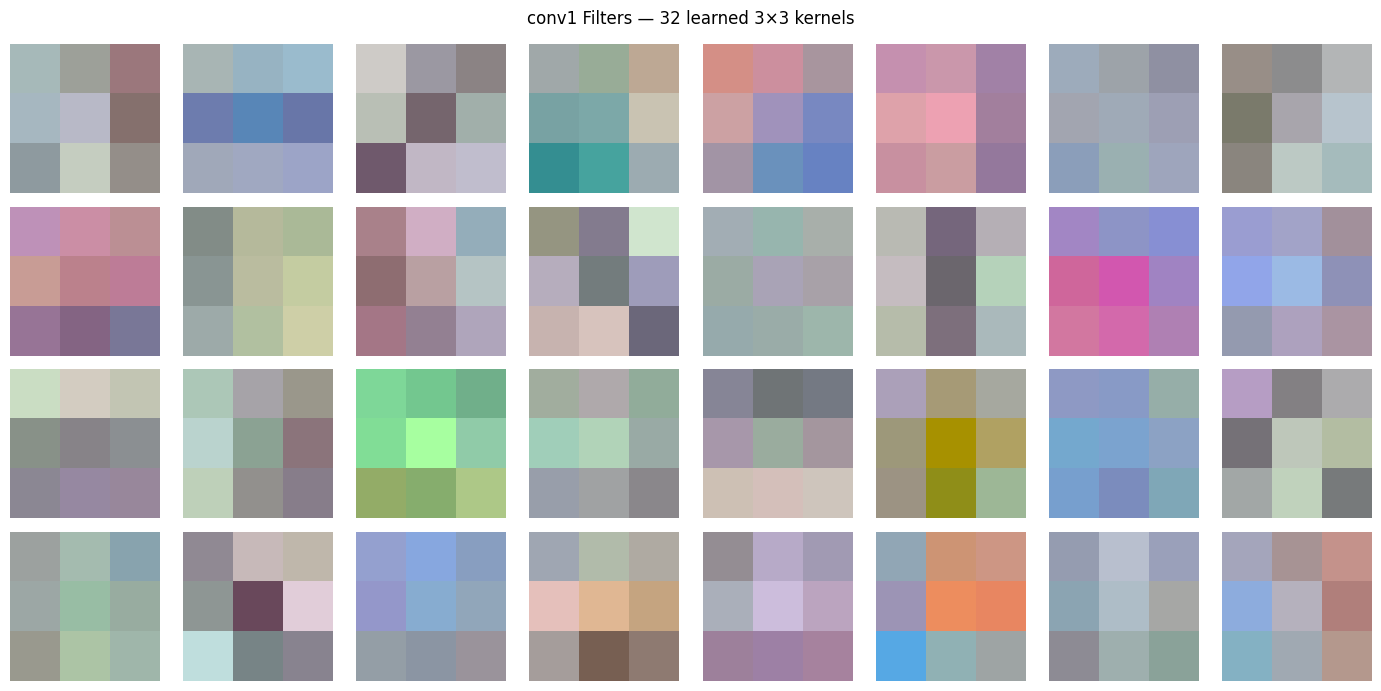

In [6]:
weights = model.conv1.weight.data.cpu()   # shape: (32, 3, 3, 3)
# normalize to [0,1] for display
w = (weights - weights.min()) / (weights.max() - weights.min())

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('conv1 Filters — 32 learned 3×3 kernels', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(w[i].permute(1, 2, 0))   # (3, 3, 3) → RGB patch
    ax.axis('off')
plt.tight_layout()
plt.show()

## Visualization 2: Feature Maps (Layer-by-Layer)

The activation map outputs at each block for one input image.

**What to look for:**
- Block 1 → edge-like patterns, still looks like the input
- Block 2 → textures and shapes
- Block 3 → sparse, abstract — most channels go dark (only a few fire)

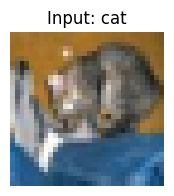

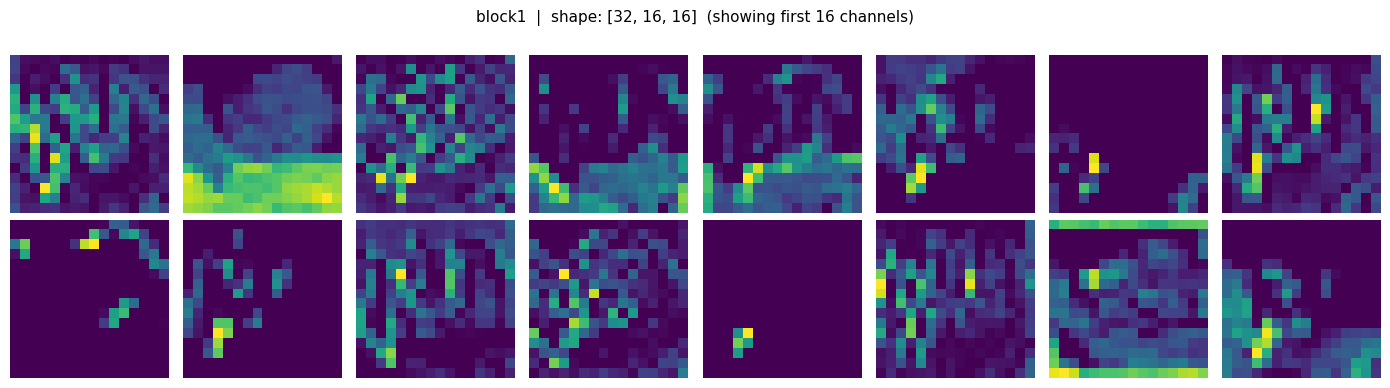

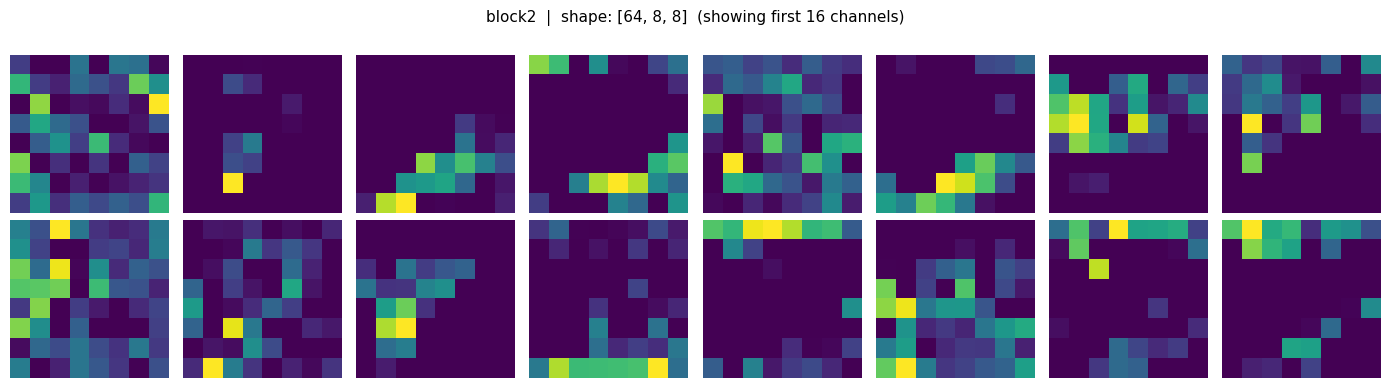

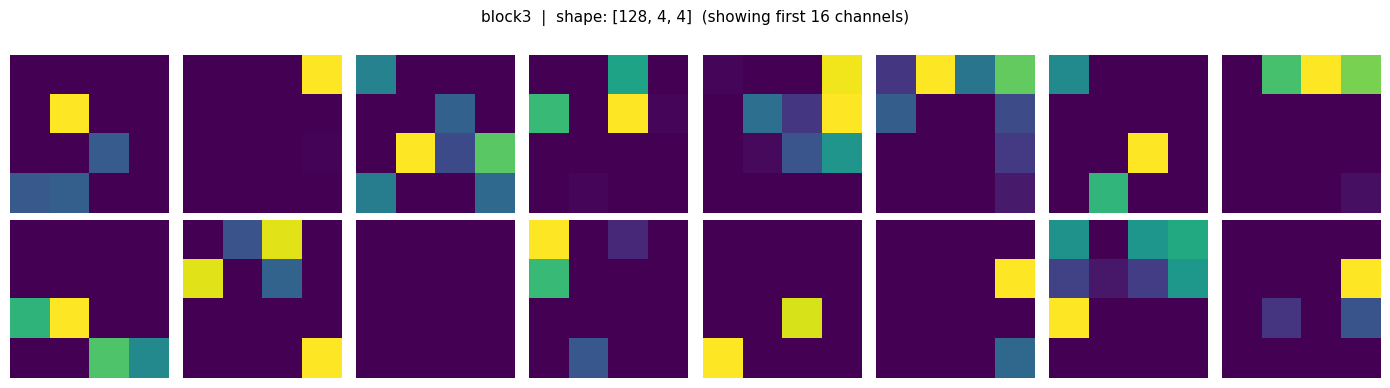

In [7]:
# picking one test image and run forward pass
img, label = testset[0]
model.eval()
with torch.no_grad():
    _ = model(img.unsqueeze(0).to(device))

# original image
plt.figure(figsize=(2, 2))
plt.imshow(denorm(img).permute(1, 2, 0))
plt.title(f'Input: {CLASSES[label]}')
plt.axis('off')
plt.show()

# feature maps per block
for block_name in ['block1', 'block2', 'block3']:
    fmap = model.feature_maps[block_name][0]   # (C, H, W)
    n    = min(16, fmap.shape[0])

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(f'{block_name}  |  shape: {list(fmap.shape)}  '
                 f'(showing first {n} channels)', fontsize=11)
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(fmap[i].numpy(), cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Visualization 3: Grad-CAM (Gradient-weighted Class Activation Mapping)

Definition: Grad-CAM (Gradient-weighted Class Activation Mapping) is a powerful technique to visualize what parts of an image a CNN focuses on when making a prediction.

A heatmap on the original image showing which regions drove the prediction.

**How it works:**
1. Forward pass → get the predicted class score
2. Backprop through `conv3` (last conv layer)
3. Average the gradients over spatial dimensions → importance weights per channel
4. Weighted sum of feature maps → upsample → overlay on image

The heatmap should light up on the object, not the background.

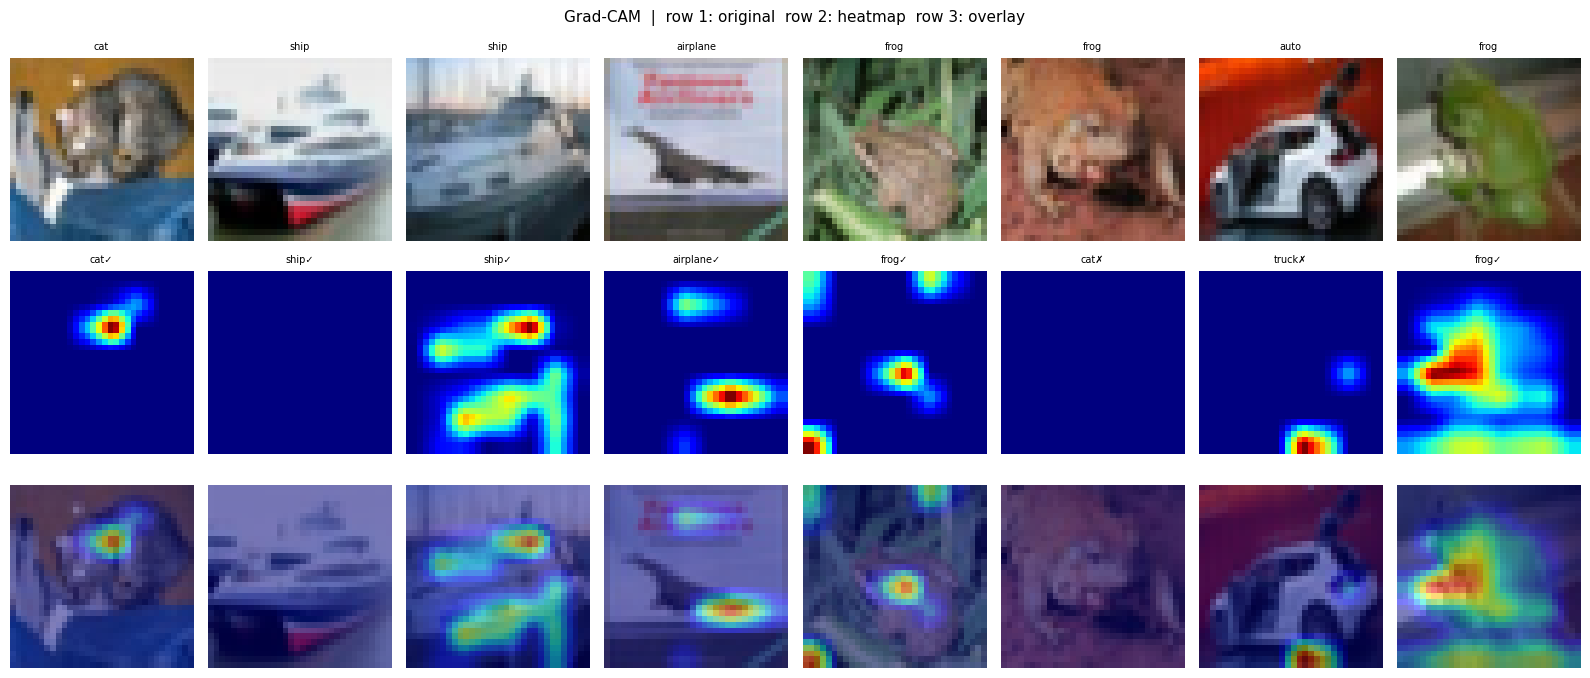

In [8]:
class GradCAM:
    def __init__(self, model, layer):
        self.grads = None
        self.acts  = None
        layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'acts', o.detach()))
        layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x):
        model.zero_grad()
        out       = model(x)
        pred      = out.argmax(1).item()
        out[0, pred].backward()                       # backprop
        weights   = self.grads[0].mean(dim=(1, 2))    # global avg pool
        cam       = (weights[:, None, None] * self.acts[0]).sum(0)
        cam       = F.relu(cam)
        cam       = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy(), pred

gradcam = GradCAM(model, model.conv3)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle('Grad-CAM  |  row 1: original  row 2: heatmap  row 3: overlay',
             fontsize=11)

for col in range(8):
    img, true_label = testset[col]
    inp = img.unsqueeze(0).to(device).requires_grad_(True)
    cam, pred = gradcam(inp)

    # upsample CAM to 32×32
    cam_up = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=(32, 32), mode='bilinear', align_corners=False
    )[0, 0].numpy()

    raw = denorm(img).permute(1, 2, 0).numpy()
    ok  = '✓' if pred == true_label else '✗'

    axes[0, col].imshow(raw)
    axes[0, col].set_title(CLASSES[true_label], fontsize=7)
    axes[0, col].axis('off')

    axes[1, col].imshow(cam_up, cmap='jet')
    axes[1, col].set_title(f'{CLASSES[pred]}{ok}', fontsize=7)
    axes[1, col].axis('off')

    overlay = 0.5 * raw + 0.5 * plt.cm.jet(cam_up)[:, :, :3]
    axes[2, col].imshow(overlay)
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()

## Visualization 5: t-SNE of Penultimate Layer

Projects the 256-dim features from `fc1` down to 2D for 1000 test images.

- Distinct color clusters = the model has separated classes well
- Overlapping clusters = the model confuses those classes (cat/dog, auto/truck are typically close)

Running t-SNE on 1000 samples × 256 features...
Done.


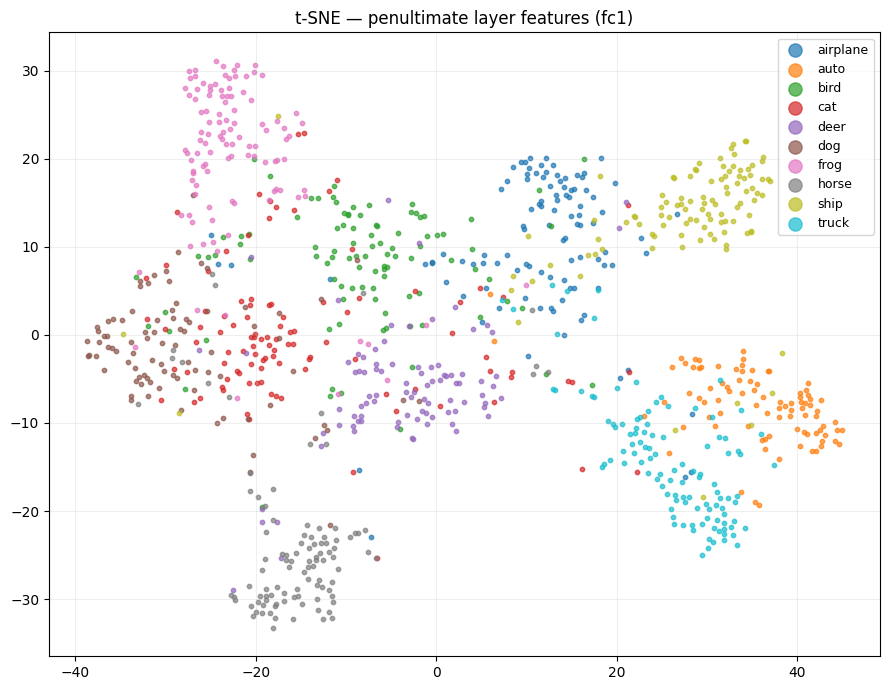

In [9]:
model.eval()
feats, gt = [], []

with torch.no_grad():
    for imgs, labels in testloader:
        _ = model(imgs.to(device))
        feats.append(model.feature_maps['penultimate'].numpy())
        gt.extend(labels.numpy())
        if len(gt) >= 1000:
            break

feats = np.vstack(feats)[:1000]
gt    = np.array(gt)[:1000]

print('Running t-SNE on 1000 samples × 256 features...')
emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(feats)
print('Done.')

fig, ax = plt.subplots(figsize=(9, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, 10))
for cls in range(10):
    mask = gt == cls
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=10, alpha=0.7, color=colors[cls], label=CLASSES[cls])
ax.legend(markerscale=3, fontsize=9)
ax.set_title('t-SNE — penultimate layer features (fc1)', fontsize=12)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
# Ablation Experiments
In Machine learning and AI, ablation experiments are performed to study how changes in model components, features and architecture changes affect model's performance.


Training 3 variants and compare them side-by-side.
Training is short (15 epochs) - enough to see the difference clearly.

In [10]:
def quick_train(model, epochs=15, label=''):
    print(f'\nTraining: {label}')
    _, tr_acc, te_acc, tr_loss = train(model, epochs=epochs)
    print(f'  Final test acc: {te_acc[-1]:.1f}%')
    return tr_acc, te_acc, tr_loss

## Ablation 1: Batch Normalization (BN)

**Question:** What does BN actually do during training?

**Expected result:** Without BN, loss starts high and training is unstable. With BN, smooth fast convergence. BN also acts as a mild regularizer.


Training: With BN
Epoch  1/15  Train: 30.3%  Test: 39.8%
Epoch  5/15  Train: 69.1%  Test: 66.6%
Epoch 10/15  Train: 80.0%  Test: 73.3%
Epoch 15/15  Train: 86.2%  Test: 75.6%
  Final test acc: 75.6%

Training: Without BN
Epoch  1/15  Train: 33.9%  Test: 43.3%
Epoch  5/15  Train: 47.3%  Test: 48.3%
Epoch 10/15  Train: 52.7%  Test: 51.3%
Epoch 15/15  Train: 56.3%  Test: 53.9%
  Final test acc: 53.9%


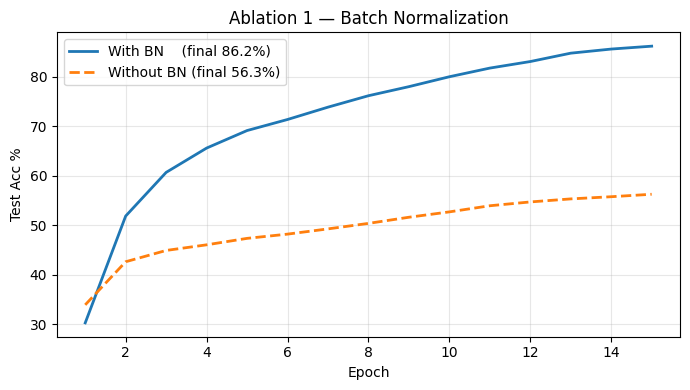


BN gain: +29.9%


In [11]:
r_bn,    _, _ = quick_train(SimpleCNN(use_bn=True),  label='With BN')
r_no_bn, _, _ = quick_train(SimpleCNN(use_bn=False), label='Without BN')

# -- plot --
ep = range(1, len(r_bn) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ep, r_bn,    label=f'With BN    (final {r_bn[-1]:.1f}%)',    linewidth=2)
ax.plot(ep, r_no_bn, label=f'Without BN (final {r_no_bn[-1]:.1f}%)', linewidth=2, linestyle='--')
ax.set_title('Ablation 1 — Batch Normalization', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc %')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nBN gain: +{r_bn[-1] - r_no_bn[-1]:.1f}%')

## Ablation 2: Activation Function

**Question:** Does the choice of ReLU vs LeakyReLU vs GELU matter?

**Why each exists:**
- **ReLU:** Fast. Problem: neurons with negative input output exactly 0 forever (dying ReLU)
- **LeakyReLU:** Fixes dying ReLU - allows a small negative gradient to flow
- **GELU:** Smooth, probabilistic - used in BERT/GPT. Slower but sometimes better

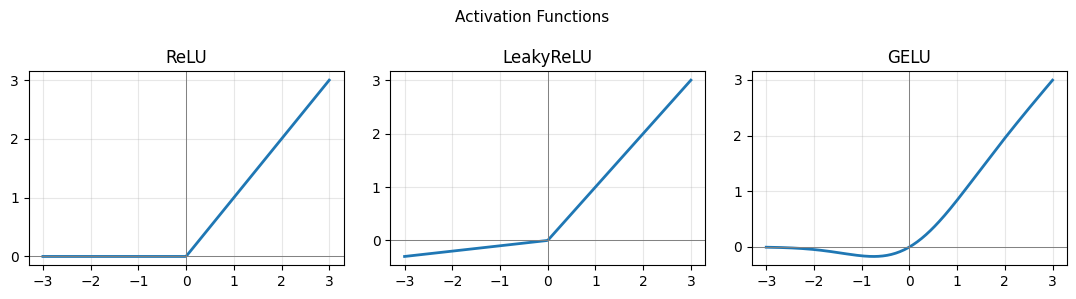


Training: relu
Epoch  1/15  Train: 32.8%  Test: 48.5%
Epoch  5/15  Train: 72.1%  Test: 70.8%
Epoch 10/15  Train: 82.7%  Test: 77.3%
Epoch 15/15  Train: 88.9%  Test: 78.6%
  Final test acc: 78.6%

Training: leaky
Epoch  1/15  Train: 41.8%  Test: 52.6%
Epoch  5/15  Train: 78.1%  Test: 75.5%
Epoch 10/15  Train: 91.0%  Test: 80.5%
Epoch 15/15  Train: 98.2%  Test: 82.0%
  Final test acc: 82.0%

Training: gelu
Epoch  1/15  Train: 43.2%  Test: 57.7%
Epoch  5/15  Train: 78.1%  Test: 73.7%
Epoch 10/15  Train: 89.3%  Test: 80.2%
Epoch 15/15  Train: 96.3%  Test: 81.1%
  Final test acc: 81.1%


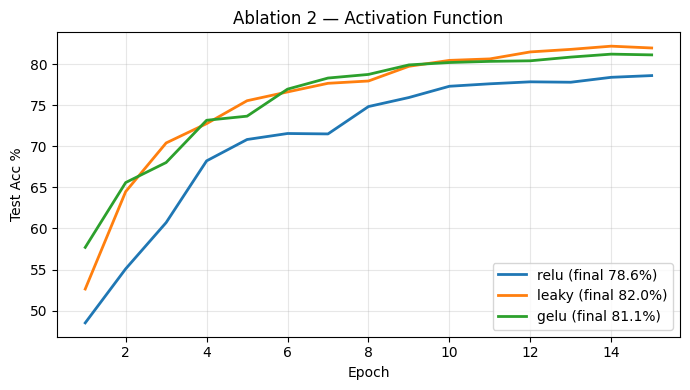

In [13]:
# visualize the three functions first
x   = torch.linspace(-3, 3, 200)
fns = {'ReLU': F.relu(x), 'LeakyReLU': F.leaky_relu(x, 0.1), 'GELU': F.gelu(x)}

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (name, vals) in zip(axes, fns.items()):
    ax.plot(x.numpy(), vals.numpy(), linewidth=2)
    ax.axhline(0, color='grey', linewidth=0.7)
    ax.axvline(0, color='grey', linewidth=0.7)
    ax.set_title(name); ax.grid(alpha=0.3)
plt.suptitle('Activation Functions', fontsize=11)
plt.tight_layout()
plt.show()

# now train
act_results = {}
for name in ['relu', 'leaky', 'gelu']:
    tr, te, _ = quick_train(SimpleCNN(activation=name), label=name)
    act_results[name] = te

ep = range(1, 16)
fig, ax = plt.subplots(figsize=(7, 4))
for name, te in act_results.items():
    ax.plot(ep, te, label=f'{name} (final {te[-1]:.1f}%)', linewidth=2)
ax.set_title('Ablation 2 — Activation Function', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc %')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()